# YOLO Models Testing - Comprehensive Evaluation
Testing 3 YOLO models on cardboard, glass, and plastic images

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score,
    precision_score, 
    recall_score, 
    f1_score,
    precision_recall_curve,
    roc_curve,
    auc
)
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [18]:
# Define paths
BASE_DIR = Path('.')
MODELS = {
    # 'YOLO_New_Medium': 'yoloMODEL_new_medium.pt',
    # 'YOLO_Old_CLS': 'yoloMODEL_old_cls.pt',
    'YOLO_Old_D': 'yoloMODEL_old_d.pt'
}

DATA_FOLDERS = {
    'cardboard': 'cardboard',
    'glass': 'glass',
    'plastic': 'plastic'
}

CLASS_NAMES = ['cardboard', 'glass', 'plastic']

# Create output directories for each model
OUTPUT_DIR = BASE_DIR / 'model_results'
OUTPUT_DIR.mkdir(exist_ok=True)

for model_name in MODELS.keys():
    model_dir = OUTPUT_DIR / model_name
    model_dir.mkdir(exist_ok=True)
    print(f"Created directory: {model_dir}")

print(f"\nModels to test: {list(MODELS.keys())}")
print(f"Classes: {CLASS_NAMES}")

Created directory: model_results/YOLO_Old_D

Models to test: ['YOLO_Old_D']
Classes: ['cardboard', 'glass', 'plastic']


In [19]:
# Load all images
def load_dataset():
    images = []
    labels = []
    
    for class_idx, (class_name, folder) in enumerate(DATA_FOLDERS.items()):
        folder_path = BASE_DIR / folder
        image_files = list(folder_path.glob('*.jpg')) + list(folder_path.glob('*.png'))
        
        for img_path in image_files:
            images.append(str(img_path))
            labels.append(class_idx)
        
        print(f"{class_name}: {len(image_files)} images (label: {class_idx})")
    
    return images, np.array(labels)

images, true_labels = load_dataset()
print(f"\nTotal images: {len(images)}")
print(f"Label distribution: {np.bincount(true_labels)}")

cardboard: 400 images (label: 0)
glass: 400 images (label: 1)
plastic: 400 images (label: 2)

Total images: 1200
Label distribution: [400 400 400]


In [20]:
# Function to get predictions from YOLO model
def get_predictions(model_path, images):
    print(f"\nLoading model: {model_path}")
    model = YOLO(model_path)
    
    predictions = []
    confidences = []
    
    print(f"Processing {len(images)} images...")
    for idx, img_path in enumerate(images):
        if (idx + 1) % 100 == 0:
            print(f"Processed {idx + 1}/{len(images)} images")
        
        results = model(img_path, verbose=False)
        
        # Get top prediction
        if len(results) > 0 and results[0].probs is not None:
            probs = results[0].probs.data.cpu().numpy()
            pred_class = np.argmax(probs)
            confidence = probs[pred_class]
        else:
            pred_class = 0  # Default to first class if no prediction
            confidence = 0.0
        
        predictions.append(pred_class)
        confidences.append(confidence)
    
    print(f"Completed predictions for {model_path}")
    return np.array(predictions), np.array(confidences)

In [21]:
# Function to calculate all metrics
def calculate_metrics(y_true, y_pred, model_name):
    metrics = {}
    
    # Overall metrics
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    metrics['precision_weighted'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['recall_weighted'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['f1_weighted'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Per-class metrics
    metrics['precision_per_class'] = precision_score(y_true, y_pred, average=None, zero_division=0)
    metrics['recall_per_class'] = recall_score(y_true, y_pred, average=None, zero_division=0)
    metrics['f1_per_class'] = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    # Confusion matrix
    metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred)
    
    return metrics

In [22]:
# Function to plot confusion matrix
def plot_confusion_matrix(cm, model_name, class_names, save_dir):
    # Regular confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {model_name.replace("_", " ")}', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_dir / '1_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Normalized confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Percentage'})
    plt.title(f'Normalized Confusion Matrix - {model_name.replace("_", " ")}', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(save_dir / '2_confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"✓ Saved confusion matrices to {save_dir}")

In [23]:
# Function to plot metrics comparison
def plot_metrics_bars(metrics, model_name, class_names, save_dir):
    # Overall metrics
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Macro-averaged metrics
    overall_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    values = [metrics[m] for m in overall_metrics]
    labels = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)', 'F1-Score\n(Macro)']
    
    bars = axes[0].bar(labels, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[0].set_ylim([0, 1])
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_title(f'Overall Metrics (Macro-Averaged) - {model_name.replace("_", " ")}', 
                      fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Weighted metrics
    weighted_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
    values_w = [metrics[m] for m in weighted_metrics]
    labels_w = ['Accuracy', 'Precision\n(Weighted)', 'Recall\n(Weighted)', 'F1-Score\n(Weighted)']
    
    bars_w = axes[1].bar(labels_w, values_w, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[1].set_ylim([0, 1])
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title(f'Overall Metrics (Weighted) - {model_name.replace("_", " ")}', 
                      fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    for bar in bars_w:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(save_dir / '3_overall_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Per-class metrics
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(class_names))
    width = 0.25
    
    bars1 = ax.bar(x - width, metrics['precision_per_class'], width, label='Precision', color='#ff7f0e')
    bars2 = ax.bar(x, metrics['recall_per_class'], width, label='Recall', color='#2ca02c')
    bars3 = ax.bar(x + width, metrics['f1_per_class'], width, label='F1-Score', color='#d62728')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Per-Class Metrics - {model_name.replace("_", " ")}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.legend()
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(save_dir / '4_per_class_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"✓ Saved metric charts to {save_dir}")

In [24]:
# Function to plot confidence distribution
def plot_confidence_distribution(confidences, model_name, save_dir):
    plt.figure(figsize=(12, 6))
    
    plt.hist(confidences, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
    plt.xlabel('Confidence Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'Prediction Confidence Distribution - {model_name.replace("_", " ")}\nMean: {np.mean(confidences):.3f} | Std: {np.std(confidences):.3f}', 
             fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.axvline(np.mean(confidences), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(confidences):.3f}')
    plt.axvline(np.median(confidences), color='green', linestyle='--', 
               linewidth=2, label=f'Median: {np.median(confidences):.3f}')
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig(save_dir / '5_confidence_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"✓ Saved confidence distribution to {save_dir}")

In [25]:
# Function to create comprehensive report
def save_detailed_report(metrics, model_name, class_names, save_dir, confidences):
    report_path = save_dir / 'detailed_metrics_report.txt'
    
    with open(report_path, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write(f"DETAILED METRICS REPORT - {model_name.replace('_', ' ')}\n")
        f.write("=" * 80 + "\n")
        
        f.write("\n--- Overall Metrics (Macro-Averaged) ---\n")
        f.write(f"Accuracy:  {metrics['accuracy']:.4f}\n")
        f.write(f"Precision: {metrics['precision_macro']:.4f}\n")
        f.write(f"Recall:    {metrics['recall_macro']:.4f}\n")
        f.write(f"F1-Score:  {metrics['f1_macro']:.4f}\n")
        
        f.write("\n--- Overall Metrics (Weighted) ---\n")
        f.write(f"Precision: {metrics['precision_weighted']:.4f}\n")
        f.write(f"Recall:    {metrics['recall_weighted']:.4f}\n")
        f.write(f"F1-Score:  {metrics['f1_weighted']:.4f}\n")
        
        f.write("\n--- Per-Class Metrics ---\n")
        for i, class_name in enumerate(class_names):
            f.write(f"\n{class_name.upper()}:\n")
            f.write(f"  Precision: {metrics['precision_per_class'][i]:.4f}\n")
            f.write(f"  Recall:    {metrics['recall_per_class'][i]:.4f}\n")
            f.write(f"  F1-Score:  {metrics['f1_per_class'][i]:.4f}\n")
        
        f.write("\n--- Confusion Matrix ---\n")
        f.write(str(metrics['confusion_matrix']) + "\n")
        
        f.write("\n--- Confidence Statistics ---\n")
        f.write(f"Mean:      {np.mean(confidences):.4f}\n")
        f.write(f"Median:    {np.median(confidences):.4f}\n")
        f.write(f"Std Dev:   {np.std(confidences):.4f}\n")
        f.write(f"Min:       {np.min(confidences):.4f}\n")
        f.write(f"Max:       {np.max(confidences):.4f}\n")
        
        f.write("\n" + "=" * 80 + "\n")
    
    print(f"✓ Saved detailed report to {report_path}")
    
    # Also print to console
    with open(report_path, 'r') as f:
        print(f.read())


TESTING MODEL: YOLO_Old_D

Loading model: yoloMODEL_old_d.pt
Processing 1200 images...
Processed 100/1200 images
Processed 200/1200 images
Processed 300/1200 images
Processed 400/1200 images
Processed 500/1200 images
Processed 600/1200 images
Processed 700/1200 images
Processed 800/1200 images
Processed 900/1200 images
Processed 1000/1200 images
Processed 1100/1200 images
Processed 1200/1200 images
Completed predictions for yoloMODEL_old_d.pt
✓ Saved detailed report to model_results/YOLO_Old_D/detailed_metrics_report.txt
DETAILED METRICS REPORT - YOLO Old D

--- Overall Metrics (Macro-Averaged) ---
Accuracy:  0.3333
Precision: 0.1111
Recall:    0.3333
F1-Score:  0.1667

--- Overall Metrics (Weighted) ---
Precision: 0.1111
Recall:    0.3333
F1-Score:  0.1667

--- Per-Class Metrics ---

CARDBOARD:
  Precision: 0.3333
  Recall:    1.0000
  F1-Score:  0.5000

GLASS:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

PLASTIC:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0

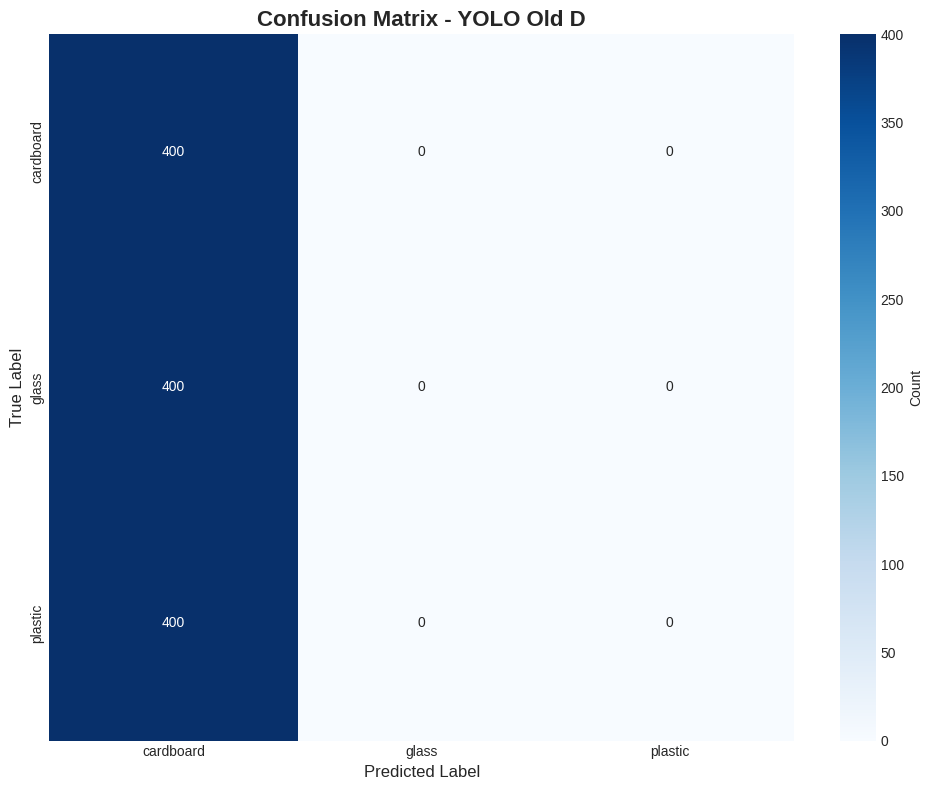

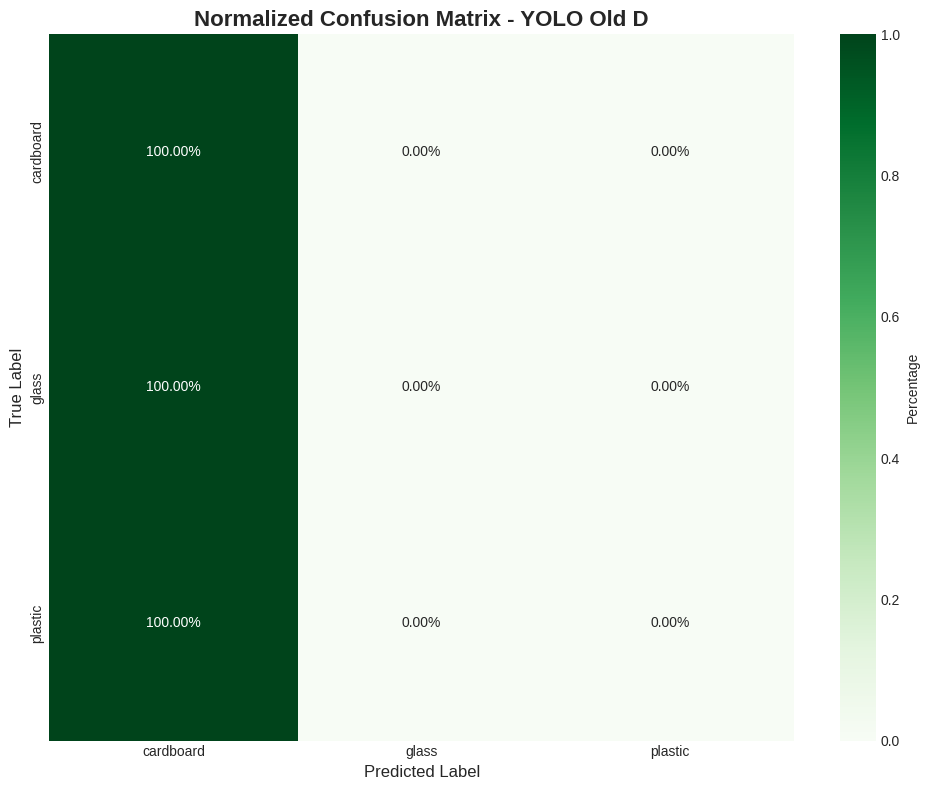

✓ Saved confusion matrices to model_results/YOLO_Old_D


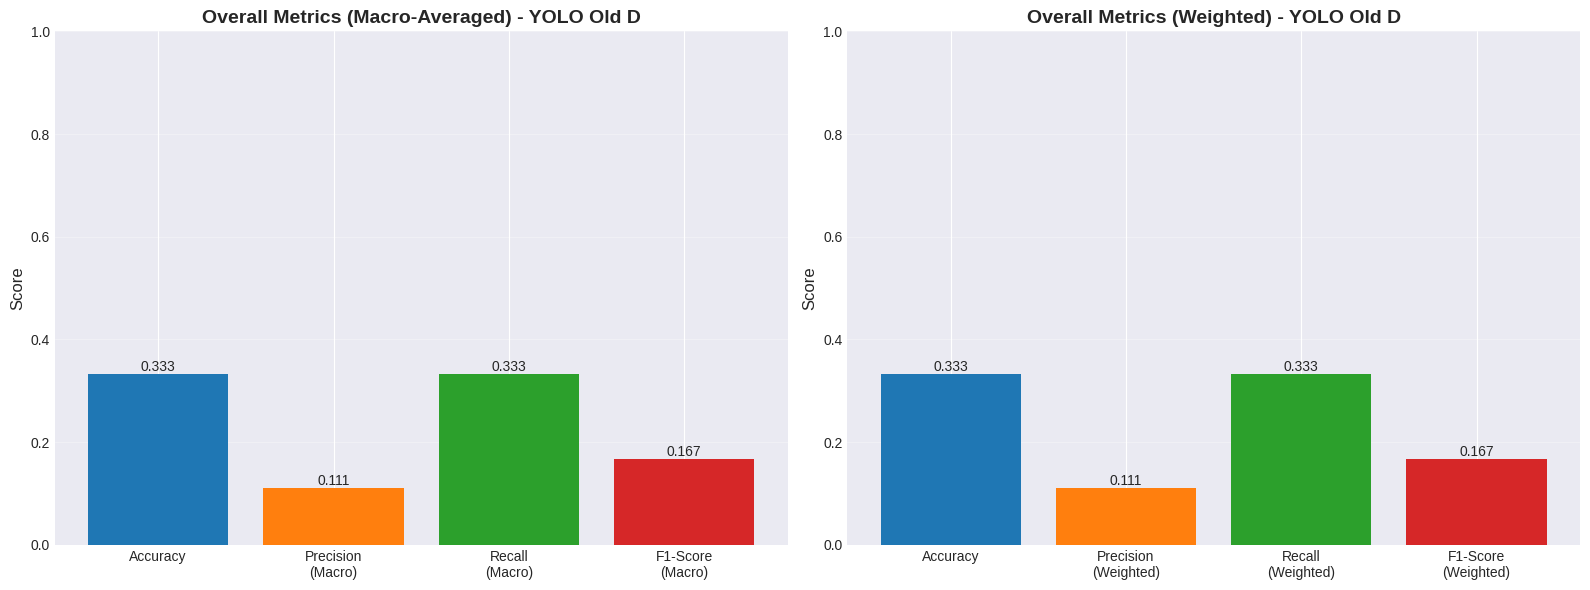

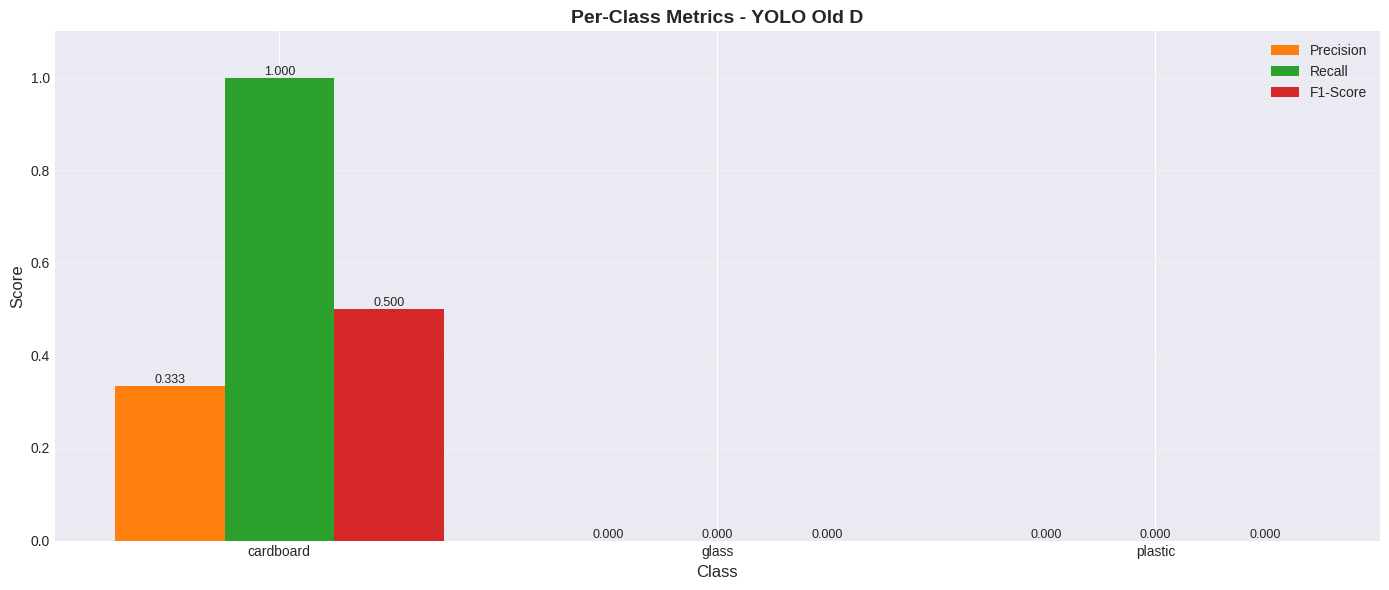

✓ Saved metric charts to model_results/YOLO_Old_D


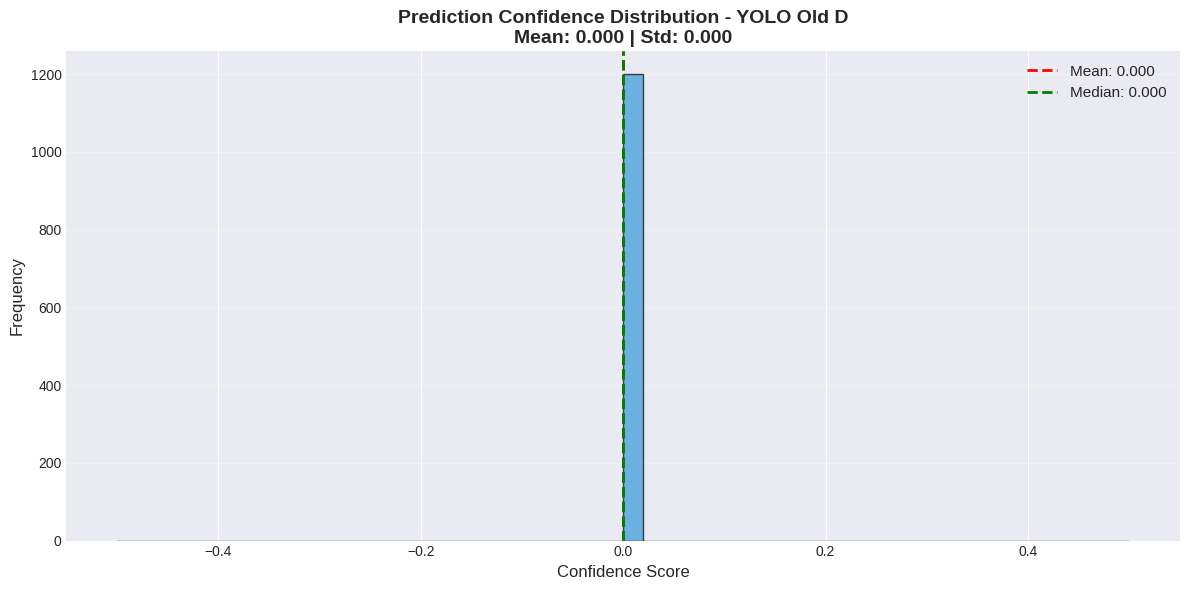

✓ Saved confidence distribution to model_results/YOLO_Old_D

✓ All graphs for YOLO_Old_D saved to: model_results/YOLO_Old_D


ALL MODELS TESTED SUCCESSFULLY!


In [26]:
# Main testing loop - Test all models
all_results = {}

for model_name, model_file in MODELS.items():
    print(f"\n{'='*80}")
    print(f"TESTING MODEL: {model_name}")
    print(f"{'='*80}")
    
    save_dir = OUTPUT_DIR / model_name
    
    # Get predictions
    predictions, confidences = get_predictions(model_file, images)
    
    # Calculate metrics
    metrics = calculate_metrics(true_labels, predictions, model_name)
    all_results[model_name] = {
        'predictions': predictions,
        'confidences': confidences,
        'metrics': metrics
    }
    
    # Save detailed report
    save_detailed_report(metrics, model_name, CLASS_NAMES, save_dir, confidences)
    
    # Plot and save confusion matrix
    plot_confusion_matrix(metrics['confusion_matrix'], model_name, CLASS_NAMES, save_dir)
    
    # Plot and save metrics
    plot_metrics_bars(metrics, model_name, CLASS_NAMES, save_dir)
    
    # Plot and save confidence distribution
    plot_confidence_distribution(confidences, model_name, save_dir)
    
    print(f"\n✓ All graphs for {model_name} saved to: {save_dir}\n")

print("\n" + "="*80)
print("ALL MODELS TESTED SUCCESSFULLY!")
print("="*80)


MODEL COMPARISON SUMMARY

Model                         Accuracy    Precision       Recall     F1-Score
--------------------------------------------------------------------------------
YOLO Old D                      0.3333       0.1111       0.3333       0.1667


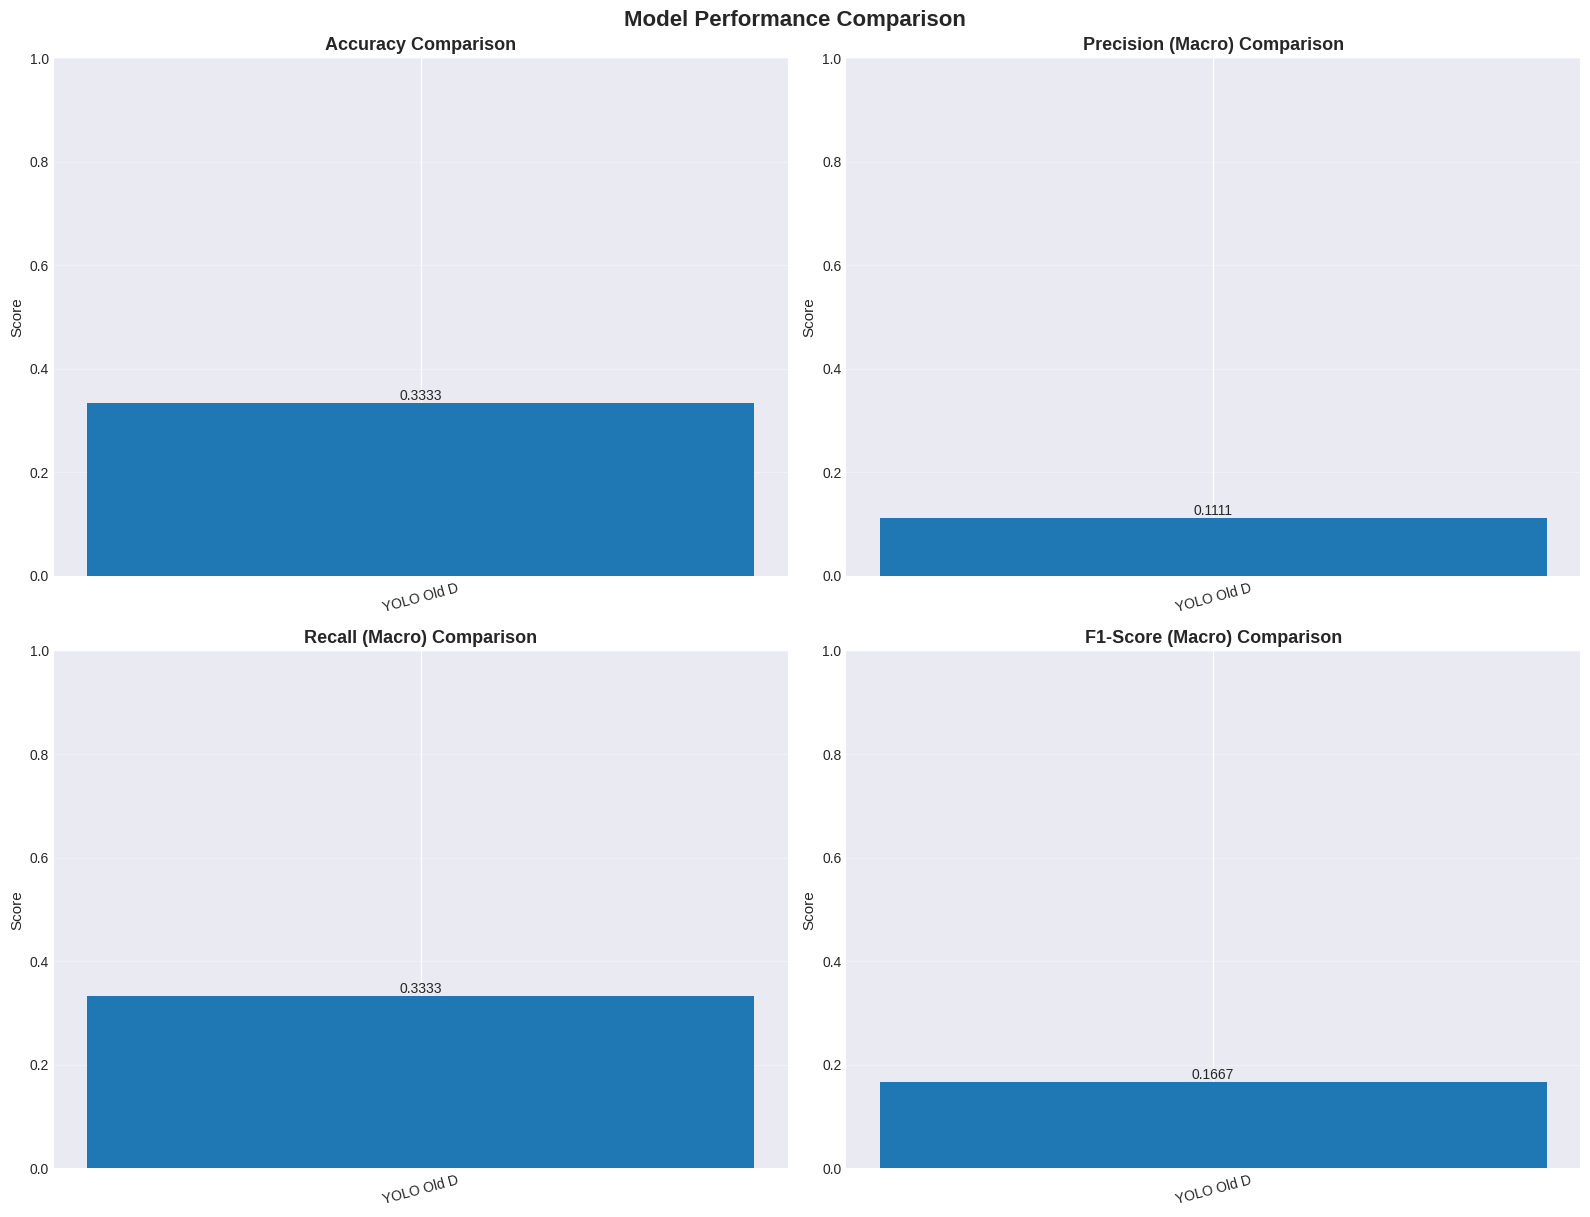


✓ Saved model comparison to model_results/comparison


In [27]:
# Compare all models side by side
comparison_dir = OUTPUT_DIR / 'comparison'
comparison_dir.mkdir(exist_ok=True)

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

comparison_data = []
for model_name, results in all_results.items():
    m = results['metrics']
    comparison_data.append({
        'Model': model_name.replace('_', ' '),
        'Accuracy': m['accuracy'],
        'Precision (Macro)': m['precision_macro'],
        'Recall (Macro)': m['recall_macro'],
        'F1-Score (Macro)': m['f1_macro']
    })

# Print comparison table
print(f"\n{'Model':<25} {'Accuracy':>12} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}")
print("-" * 80)
for data in comparison_data:
    print(f"{data['Model']:<25} {data['Accuracy']:>12.4f} {data['Precision (Macro)']:>12.4f} "
          f"{data['Recall (Macro)']:>12.4f} {data['F1-Score (Macro)']:>12.4f}")

# Plot model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_compare = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics_to_compare):
    ax = axes[idx // 2, idx % 2]
    values = [data[metric] for data in comparison_data]
    model_names = [data['Model'] for data in comparison_data]
    
    bars = ax.bar(model_names, values, color=colors)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.savefig(comparison_dir / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"\n✓ Saved model comparison to {comparison_dir}")

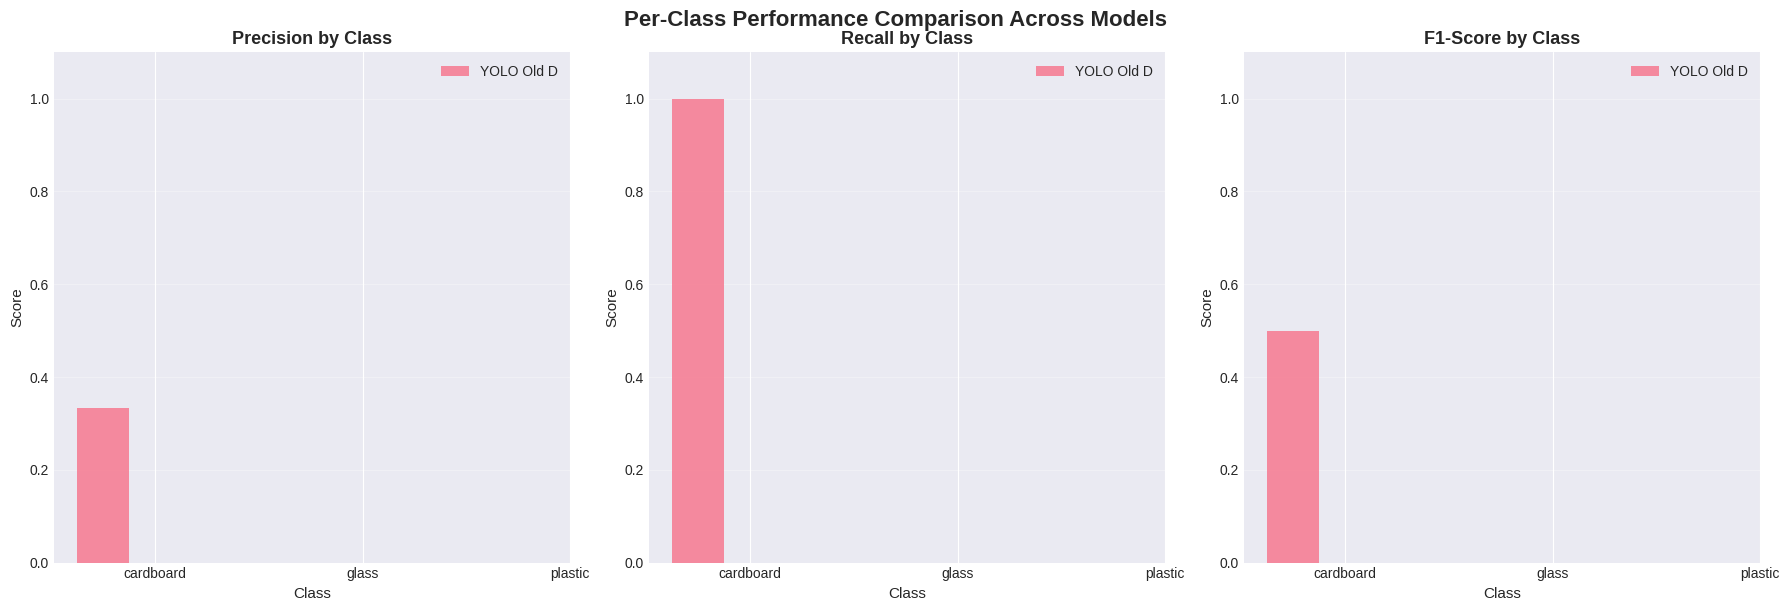

✓ Saved per-class comparison to model_results/comparison


In [28]:
# Per-class comparison across models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metric_names = ['Precision', 'Recall', 'F1-Score']
metric_keys = ['precision_per_class', 'recall_per_class', 'f1_per_class']

for idx, (metric_name, metric_key) in enumerate(zip(metric_names, metric_keys)):
    ax = axes[idx]
    x = np.arange(len(CLASS_NAMES))
    width = 0.25
    
    for i, (model_name, results) in enumerate(all_results.items()):
        values = results['metrics'][metric_key]
        offset = (i - 1) * width
        ax.bar(x + offset, values, width, label=model_name.replace('_', ' '), alpha=0.8)
    
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{metric_name} by Class', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES)
    ax.legend()
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Per-Class Performance Comparison Across Models', fontsize=16, fontweight='bold', y=1.01)
plt.savefig(comparison_dir / 'per_class_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✓ Saved per-class comparison to {comparison_dir}")

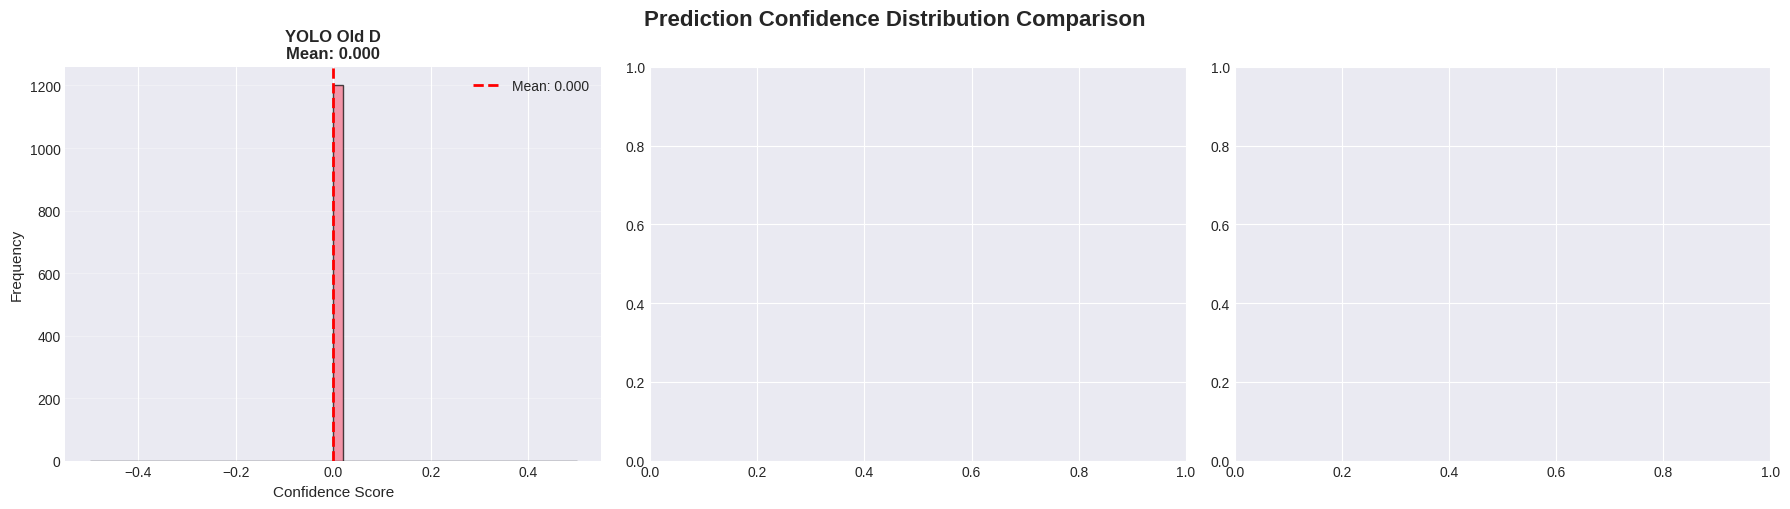

✓ Saved confidence comparison to model_results/comparison


In [29]:
# Confidence distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, results) in enumerate(all_results.items()):
    ax = axes[idx]
    confidences = results['confidences']
    
    ax.hist(confidences, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Confidence Score', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{model_name.replace("_", " ")}\nMean: {np.mean(confidences):.3f}', 
                fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.axvline(np.mean(confidences), color='red', linestyle='--', 
              linewidth=2, label=f'Mean: {np.mean(confidences):.3f}')
    ax.legend()

plt.tight_layout()
plt.suptitle('Prediction Confidence Distribution Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.savefig(comparison_dir / 'confidence_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✓ Saved confidence comparison to {comparison_dir}")

In [30]:
# Save comparison summary report
summary_path = comparison_dir / 'comparison_summary.txt'
with open(summary_path, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("MODEL COMPARISON SUMMARY\n")
    f.write("=" * 80 + "\n\n")
    
    f.write(f"Total images tested: {len(images)}\n")
    f.write(f"Classes: {CLASS_NAMES}\n")
    f.write(f"Models tested: {len(MODELS)}\n\n")
    
    f.write("Comparison Table:\n")
    f.write(f"{'Model':<25} {'Accuracy':>12} {'Precision':>12} {'Recall':>12} {'F1-Score':>12}\n")
    f.write("-" * 80 + "\n")
    for data in comparison_data:
        f.write(f"{data['Model']:<25} {data['Accuracy']:>12.4f} {data['Precision (Macro)']:>12.4f} "
              f"{data['Recall (Macro)']:>12.4f} {data['F1-Score (Macro)']:>12.4f}\n")
    
    best_model = max(comparison_data, key=lambda x: x['F1-Score (Macro)'])
    f.write(f"\n🏆 Best Model (by F1-Score): {best_model['Model']}\n")
    f.write(f"   - Accuracy: {best_model['Accuracy']:.4f}\n")
    f.write(f"   - F1-Score: {best_model['F1-Score (Macro)']:.4f}\n")
    f.write(f"   - Precision: {best_model['Precision (Macro)']:.4f}\n")
    f.write(f"   - Recall: {best_model['Recall (Macro)']:.4f}\n")
    f.write("\n" + "=" * 80 + "\n")

print(f"✓ Saved comparison summary to {summary_path}")

# Final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"\nTotal images tested: {len(images)}")
print(f"Classes: {CLASS_NAMES}")
print(f"Models tested: {len(MODELS)}")

best_model = max(comparison_data, key=lambda x: x['F1-Score (Macro)'])
print(f"\n🏆 Best Model (by F1-Score): {best_model['Model']}")
print(f"   - Accuracy: {best_model['Accuracy']:.4f}")
print(f"   - F1-Score: {best_model['F1-Score (Macro)']:.4f}")
print(f"   - Precision: {best_model['Precision (Macro)']:.4f}")
print(f"   - Recall: {best_model['Recall (Macro)']:.4f}")

print("\n" + "="*80)
print("📁 OUTPUT STRUCTURE:")
print("="*80)
print(f"model_results/")
for model_name in MODELS.keys():
    print(f"├── {model_name}/")
    print(f"│   ├── 1_confusion_matrix.png")
    print(f"│   ├── 2_confusion_matrix_normalized.png")
    print(f"│   ├── 3_overall_metrics.png")
    print(f"│   ├── 4_per_class_metrics.png")
    print(f"│   ├── 5_confidence_distribution.png")
    print(f"│   └── detailed_metrics_report.txt")
print(f"└── comparison/")
print(f"    ├── model_comparison.png")
print(f"    ├── per_class_comparison.png")
print(f"    ├── confidence_comparison.png")
print(f"    └── comparison_summary.txt")
print("\n" + "="*80)
print("✅ ALL GRAPHS AND REPORTS SAVED SUCCESSFULLY!")
print("="*80)

✓ Saved comparison summary to model_results/comparison/comparison_summary.txt

FINAL SUMMARY

Total images tested: 1200
Classes: ['cardboard', 'glass', 'plastic']
Models tested: 1

🏆 Best Model (by F1-Score): YOLO Old D
   - Accuracy: 0.3333
   - F1-Score: 0.1667
   - Precision: 0.1111
   - Recall: 0.3333

📁 OUTPUT STRUCTURE:
model_results/
├── YOLO_Old_D/
│   ├── 1_confusion_matrix.png
│   ├── 2_confusion_matrix_normalized.png
│   ├── 3_overall_metrics.png
│   ├── 4_per_class_metrics.png
│   ├── 5_confidence_distribution.png
│   └── detailed_metrics_report.txt
└── comparison/
    ├── model_comparison.png
    ├── per_class_comparison.png
    ├── confidence_comparison.png
    └── comparison_summary.txt

✅ ALL GRAPHS AND REPORTS SAVED SUCCESSFULLY!
